In [204]:
import numpy as np
import matplotlib.pyplot as plt
import json
from ast import literal_eval
import statsmodels.api as sm
import pandas as pd

# Read in File(s)

In [233]:
f = open("rail-desktop-3-human-text-2024081615.log", "r")
info = ""
d = 0
positions = []
for line in f:
    if 'Created new route legs for bot 1 ' in line:
        arrs = []
        arr = ""
        c = 0
        for character in line:
            if character == "(":
                c = 1
            if character == ")":
                arr = arr + character
                c = 0
                arrs.append(literal_eval(arr))
                arr = ""
            if c:
                arr = arr + character
        for arr in arrs:
            if arr not in positions:
                positions.append(arr)
            
print(positions)

[(42179, -6306, 1571), (42179, -2039, 1571), (39432, 77584, -1571), (39433, 77582, -1570), (39432, 90196, -1571), (39433, 90194, -1570), (39432, 9986, -1571), (80045, -4172, 1571), (80046, -4168, 1570), (80045, -2039, 1571), (95956, -3123, -1571)]


In [41]:
positions = [(x[0], x[1]) for x in positions]
positions

[(42179, -6306),
 (42179, -2039),
 (39432, 77584),
 (39433, 77582),
 (39432, 90196),
 (39433, 90194),
 (39432, 9986),
 (80045, -4172),
 (80046, -4168),
 (80045, -2039),
 (95956, -3123)]

In [39]:
estimated_distance = 0
for i in range(len(positions)-2):
    d = np.linalg.norm(np.asarray(positions[i])-np.asarray(positions[i+1]), ord=1)
    estimated_distance += d
print(estimated_distance)

583866.0


In [25]:
f = open("rail-desktop-3-human-text-2024081615.log", "r")
info = ""
d = 0
positions = []
for line in f:
    if 'Message Symbotic.SystemState.Event.Bot.Updated' in line:
        if 'bot 23,' in line:
            arrs = []
            arr = ""
            c = 0
            for character in line:
                if character == "(":
                    c = 1
                if character == ")":
                    arr = arr + character
                    c = 0
                    arrs.append(literal_eval(arr))
                    arr = ""
                if c:
                    arr = arr + character
            if arrs[0] not in positions:
                positions.append(arrs[0])
print(positions)

[(59088, -3123, -1571), (59088, -3071, -1571), (59088, -2686, -1571), (59088, -1938, -1571), (59088, -1293, -1571), (59088, -1006, -1571), (59088, -991, -1571), (59088, -939, -1571), (59088, -554, -1571), (59088, 206, -1571), (59088, 1162, -1571), (59088, 1893, -1572), (59089, 2283, -1595), (59134, 2520, -2076), (58974, 2401, -2682), (58478, 2315, -3141), (57845, 2315, 3141), (56838, 2315, -3141), (55456, 2315, -3141), (53700, 2313, -3141), (51890, 2313, -3141), (50420, 2313, -3141), (49296, 2313, -3141), (48519, 2313, -3140), (48091, 2313, -3140), (47827, 2288, -2877), (47605, 2176, -2393), (47668, 2281, -1995), (47733, 2592, -1595), (47733, 2935, -1571), (47733, 3639, -1572), (47735, 4719, -1572), (47737, 6092, -1572), (47738, 7225, -1571), (47738, 8185, -1571), (47738, 9191, -1571), (47738, 10523, -1571), (47738, 12229, -1571), (47738, 14310, -1571), (47738, 16765, -1571), (47738, 19595, -1571), (47738, 22799, -1571), (47738, 26377, -1571), (47738, 30210, -1571), (47738, 34051, -157

In [26]:
positions = [(x[0], x[1]) for x in positions]
positions

[(59088, -3123),
 (59088, -3071),
 (59088, -2686),
 (59088, -1938),
 (59088, -1293),
 (59088, -1006),
 (59088, -991),
 (59088, -939),
 (59088, -554),
 (59088, 206),
 (59088, 1162),
 (59088, 1893),
 (59089, 2283),
 (59134, 2520),
 (58974, 2401),
 (58478, 2315),
 (57845, 2315),
 (56838, 2315),
 (55456, 2315),
 (53700, 2313),
 (51890, 2313),
 (50420, 2313),
 (49296, 2313),
 (48519, 2313),
 (48091, 2313),
 (47827, 2288),
 (47605, 2176),
 (47668, 2281),
 (47733, 2592),
 (47733, 2935),
 (47733, 3639),
 (47735, 4719),
 (47737, 6092),
 (47738, 7225),
 (47738, 8185),
 (47738, 9191),
 (47738, 10523),
 (47738, 12229),
 (47738, 14310),
 (47738, 16765),
 (47738, 19595),
 (47738, 22799),
 (47738, 26377),
 (47738, 30210),
 (47738, 34051),
 (47738, 37891),
 (47738, 41731),
 (47738, 45571),
 (47738, 49411),
 (47738, 53251),
 (47738, 57091),
 (47738, 60862),
 (47738, 64335),
 (47738, 67496),
 (47738, 70349),
 (47738, 72896),
 (47738, 75142),
 (47738, 77093),
 (47738, 78756),
 (47738, 80104),
 (47738, 81

In [27]:
true_distance = 0
for i in range(len(positions)-2):
    d = np.linalg.norm(np.asarray(positions[i])-np.asarray(positions[i+1]), ord=1)
    true_distance += d
print(true_distance)

687194.0


In [28]:
percent_dif = (true_distance - estimated_distance) / (estimated_distance)
print(percent_dif)

0.1769721134643908


# Loop

In [32]:
bots = range(1, 41)
percent_differences = []
estimated_distances = []
true_distances = []

for bot in bots:
    f = open("rail-desktop-3-human-text-2024081615.log", "r")
    info = ""
    d = 0
    positions = []
    for line in f:
        if ('Created new route legs for bot ' + str(bot) + ' ') in line:
            arrs = []
            arr = ""
            c = 0
            for character in line:
                if character == "(":
                    c = 1
                if character == ")":
                    arr = arr + character
                    c = 0
                    arrs.append(literal_eval(arr))
                    arr = ""
                if c:
                    arr = arr + character
            for arr in arrs:
                if arr not in positions:
                    positions.append(arr)
    positions = [(x[0], x[1]) for x in positions]
    estimated_distance = 0
    for i in range(len(positions)-2):
        d = np.linalg.norm(np.asarray(positions[i])-np.asarray(positions[i+1]), ord=1)
        estimated_distance += d
    estimated_distances.append(estimated_distance)
    print(estimated_distance)


    f = open("rail-desktop-3-human-text-2024081615.log", "r")
    info = ""
    d = 0
    positions = []
    for line in f:
        if 'Message Symbotic.SystemState.Event.Bot.Updated' in line:
            if ('bot ' + str(bot) + ',') in line:
                arrs = []
                arr = ""
                c = 0
                for character in line:
                    if character == "(":
                        c = 1
                    if character == ")":
                        arr = arr + character
                        c = 0
                        arrs.append(literal_eval(arr))
                        arr = ""
                    if c:
                        arr = arr + character
                if arrs[0] not in positions:
                    positions.append(arrs[0])
    positions = [(x[0], x[1]) for x in positions]
    true_distance = 0
    for i in range(len(positions)-2):
        d = np.linalg.norm(np.asarray(positions[i])-np.asarray(positions[i+1]), ord=1)
        true_distance += d
    true_distances.append(true_distance)
    print(true_distance)

    percent_dif = (true_distance - estimated_distance) / (estimated_distance)
    percent_differences.append(percent_dif)
    print(percent_dif)

236373.0
260390.0
0.10160635944037602
364760.0
450780.0
0.23582629674306393
485059.0
533547.0
0.0999630972727029
559182.0
573721.0
0.02600047927150731
521728.0
542360.0
0.03954551030421982
741780.0
756339.0
0.019627113160236187
635561.0
655805.0
0.0318521746929091
85920.0
220673.0
1.5683542830540038
281630.0
348766.0
0.23838369491886519
839120.0
806202.0
-0.03922919248736772
285271.0
391935.0
0.37390411223012504
561133.0
592223.0
0.05540575941889
379506.0
415928.0
0.0959721321929034
660297.0
686785.0
0.04011528145667783
591136.0
623605.0
0.05492644670600336
411001.0
451073.0
0.09749854623224762
583774.0
610854.0
0.04638781446244608
399309.0
577704.0
0.4467592766504136
358958.0
415927.0
0.15870658962887024
462303.0
498676.0
0.07867783682995784
392052.0
413498.0
0.054701927295358777
411846.0
412716.0
0.002112440086828572
583866.0
687194.0
0.1769721134643908
713874.0
641247.0
-0.10173644088452584
640843.0
647495.0
0.01038007749167893
457404.0
465080.0
0.016781663474740055
481661.0
488793.

In [36]:
print(percent_differences)
print(np.average(percent_differences)*100)
print(np.max(percent_differences)*100)
print(np.min(percent_differences)*100)

[0.10160635944037602, 0.23582629674306393, 0.0999630972727029, 0.02600047927150731, 0.03954551030421982, 0.019627113160236187, 0.0318521746929091, 1.5683542830540038, 0.23838369491886519, -0.03922919248736772, 0.37390411223012504, 0.05540575941889, 0.0959721321929034, 0.04011528145667783, 0.05492644670600336, 0.09749854623224762, 0.04638781446244608, 0.4467592766504136, 0.15870658962887024, 0.07867783682995784, 0.054701927295358777, 0.002112440086828572, 0.1769721134643908, -0.10173644088452584, 0.01038007749167893, 0.016781663474740055, 0.014807094616338046, 0.5114716289541512, 0.12425234389160153, 1.1298378093958203, 0.06174684177243114, 0.18313080143261198, 0.0992166750843529, 0.07463761770956881, 0.13302846265124033, 0.06157339951076603, 0.3529801083063876, 0.016636584370098198, 0.004317196603042746, 0.04290604343720491]
16.85009500210785
156.83542830540037
-10.173644088452583


# Avg Task Distance

In [42]:
f = open("rail-desktop-3-human-text-2024081615.log", "r")
info = ""
d = 0
positions = []
for line in f:
    if 'Created new route legs for bot 1 ' in line:
        arrs = []
        arr = ""
        c = 0
        for character in line:
            if character == "(":
                c = 1
            if character == ")":
                arr = arr + character
                c = 0
                arrs.append(literal_eval(arr))
                arr = ""
            if c:
                arr = arr + character
        for arr in arrs:
            if arr not in positions:
                positions.append(arr)
print(positions)

[(42179, -6306, 1571), (42179, -2039, 1571), (39432, 77584, -1571), (39433, 77582, -1570), (39432, 90196, -1571), (39433, 90194, -1570), (39432, 9986, -1571), (80045, -4172, 1571), (80046, -4168, 1570), (80045, -2039, 1571), (95956, -3123, -1571)]


# Expected and Actual

In [234]:
bots = range(1, 41, 1)

info = ""
d = 0
duration_percent_diff = []
distance_percent_diff = []
error_lines = []
for bot in bots:
    f = open("rail-desktop-3-human-text-2024081615.log", "r")
    duration_bot = []
    distance_bot = []
    for line in f:
        if 'Event of type=\"Task\"' in line:
            if 'Bot ' + str(bot) + "," in line:
                if bot == 14:
                    print(line)
                values = (line[102:].replace('actual', '').replace('duration', '').replace('distance', '').replace('expected', '').replace(' ', '').replace('ms', '').replace('mm', '').split(",")[:4])
                values = [literal_eval(x) for x in values]
                
                if values[1] == 0:
                    error_lines.append(line)
                else:
                    duration_bot.append(((values[0] - values[1])/values[1])*100)
                    distance_bot.append(((values[2] - values[3])/values[3])*100)
    duration_percent_diff.append(duration_bot)
    distance_percent_diff.append(distance_bot)
    
duration_percent_diff = np.asarray(duration_percent_diff)
distance_percent_diff = np.asarray(distance_percent_diff)

2024-08-16T15:36:18.9340474Z Info 10 [R] Event of type="Task" publishing with value="Bot 14, Task 19: 84500ms actual duration, 51945ms expected duration, 215798mm actual distance, 452146mm expected distance, 0ms start offset, 0 hops, Complete, Outbound"

2024-08-16T15:36:32.0258727Z Info 19 [R] Event of type="Task" publishing with value="Bot 14, Task 107: 19500ms actual duration, 1686ms expected duration, 1067mm actual distance, 8285mm expected distance, 0ms start offset, 0 hops, Complete, EmergencyCharge"



ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (40,) + inhomogeneous part.

In [149]:
print(duration_percent_diff)
[print(len(x)) for x in distance_percent_diff]
avgs = [np.average(x) for x in distance_percent_diff]

[[-100.0], [-99.07745673272078], [-100.0, -78.29672714645368, 51.23456790123457], [-98.77612963234934, -53.18604944273393], [-100.0, -87.81699248402151, 64.37592867756315], [-100.0, 167.538644470868, -88.35138868087797, 71.91081475307357], [-89.52733365914962, -68.9177016860561], [-28.727405070969308], [-76.93926378599637], [32.11273620155866, 427.39026879891117, 72.2158438576349], [68.52417760201331, 564.6216768916156], [101.95780269910664, 58.25619587936698, 75.17030446267205], [65.6581145094603, 148.16573154941736, 96.4799645782599], [62.672056983347765, 1056.5836298932384], [52.35322658903445, 50.34934111612276], [53.146640286127386, 124.80269116315176], [45.44928561096736, 185.90476678889203, 42.22222222222222, 615.9904534606205], [57.82516916885321, 129.80484635560796], [178.77953876815033, 75.55521467164357], [269.3913514978989, 234.27218422111486], [160.5831161807365, 204.30078441979984], [56.102879230883595, 444.21768707482994], [49.76430535550609, 88.1376314054075, 53.6524862

In [150]:
print(distance_percent_diff)

[[-48.50802245379981], [-5.04357627910813], [-0.0035175658444356506, 2.29682917755736, -0.0030622806641474303], [-0.005951672419950006, -0.0012528345381425474], [-0.0023632281696797826, -0.0017336230410059637, -0.0010409293417162843], [-0.0009163467089407949, -87.18938480096502, -0.002171062344226277, 4.185479747152198], [-0.0017396674625645308, 2.7942523221839433], [23.68396464410517], [-29.464058748764298], [-0.002119060953274706, -61.04164137428676, -0.0010557135215787843], [-45.46242226479993, -48.0], [-0.001113019733839881, 2.2532195598098177, -60.666738165701915], [-0.0031755608834410382, 7.2964810323525375, -60.93471782027068], [-52.27249605216014, -87.12130356065177], [-11.98216441999126, -0.0015626526027932414], [-0.0028960995331487552, -36.77159808197654], [-0.0007775535831612997, 31.781269774309216, -7.605892976816565, -48.04941482444733], [-0.00515357658214801, 20.028631870737136], [-0.006475845097785262, 6.527203299914325], [25.86094866796621, 17.097882832350926], [-21.370

[-48.50802245379981, -5.04357627910813, 0.7634164436829257, -0.0036022534790462767, -0.0017125935174673434, -20.751748115716495, 1.3962563273606894, 23.68396464410517, -29.464058748764298, -20.348272049587205, -46.73121113239996, -19.471543875208646, -17.88047078293386, -69.69689980640595, -5.991863536297027, -18.387247090754844, -5.968703895134461, 10.011739147077494, 3.2603637274082695, 21.479415750158566, -7.5171668547218395, -39.800260497355026, -1.7299134852023041, -5.778861660661666, 0.8805579416703321, -43.6902778506283, -17.24476013963103, -39.518931647483754, -21.434896714978038, 26.452836695982068, -13.289428508485976, -12.143291580933088, -24.42016030436725, 7.972945156543652, -0.000825082508250825, -56.28958953134777, 8.313010951578141, -1.5600014347178055, -9.62383430024902, -24.30305412833659]
-13.05949198872869


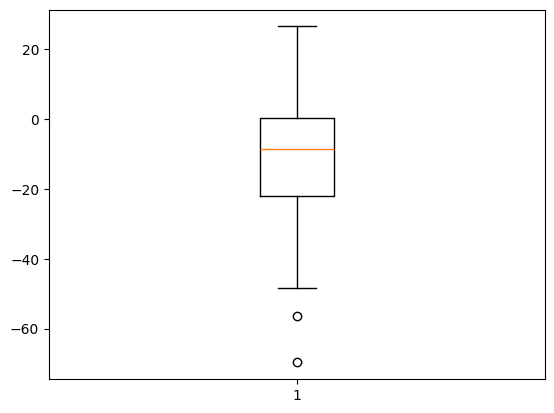

In [151]:
print(avgs)
print(np.average(avgs))
plt.title("")
plt.boxplot(avgs)
plt.show()

[-48.50802245379981, -5.04357627910813, -0.0035175658444356506, 2.29682917755736, -0.0030622806641474303, -0.005951672419950006, -0.0012528345381425474, -0.0023632281696797826, -0.0017336230410059637, -0.0010409293417162843, -0.0009163467089407949, -87.18938480096502, -0.002171062344226277, 4.185479747152198, -0.0017396674625645308, 2.7942523221839433, 23.68396464410517, -29.464058748764298, -0.002119060953274706, -61.04164137428676, -0.0010557135215787843, -45.46242226479993, -48.0, -0.001113019733839881, 2.2532195598098177, -60.666738165701915, -0.0031755608834410382, 7.2964810323525375, -60.93471782027068, -52.27249605216014, -87.12130356065177, -11.98216441999126, -0.0015626526027932414, -0.0028960995331487552, -36.77159808197654, -0.0007775535831612997, 31.781269774309216, -7.605892976816565, -48.04941482444733, -0.00515357658214801, 20.028631870737136, -0.006475845097785262, 6.527203299914325, 25.86094866796621, 17.097882832350926, -21.370280473332322, 6.335946763888643, -18.5926

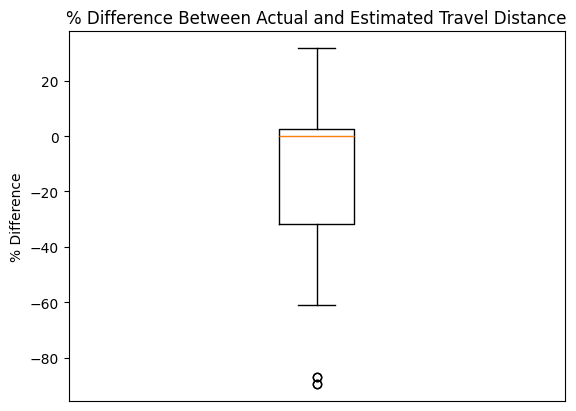

In [152]:
l_distance = []
for list in distance_percent_diff:
    for item in list:
        l_distance.append(item)
print(l_distance)
plt.boxplot(l_distance)
plt.title("% Difference Between Actual and Estimated Travel Distance")
plt.ylabel("% Difference")
plt.xticks(ticks=[], labels=[])
plt.show()

[-100.0, -99.07745673272078, -100.0, -78.29672714645368, 51.23456790123457, -98.77612963234934, -53.18604944273393, -100.0, -87.81699248402151, 64.37592867756315, -100.0, 167.538644470868, -88.35138868087797, 71.91081475307357, -89.52733365914962, -68.9177016860561, -28.727405070969308, -76.93926378599637, 32.11273620155866, 427.39026879891117, 72.2158438576349, 68.52417760201331, 564.6216768916156, 101.95780269910664, 58.25619587936698, 75.17030446267205, 65.6581145094603, 148.16573154941736, 96.4799645782599, 62.672056983347765, 1056.5836298932384, 52.35322658903445, 50.34934111612276, 53.146640286127386, 124.80269116315176, 45.44928561096736, 185.90476678889203, 42.22222222222222, 615.9904534606205, 57.82516916885321, 129.80484635560796, 178.77953876815033, 75.55521467164357, 269.3913514978989, 234.27218422111486, 160.5831161807365, 204.30078441979984, 56.102879230883595, 444.21768707482994, 49.76430535550609, 88.1376314054075, 53.65248620830093, 64.93921684416298, 92.57881197040827

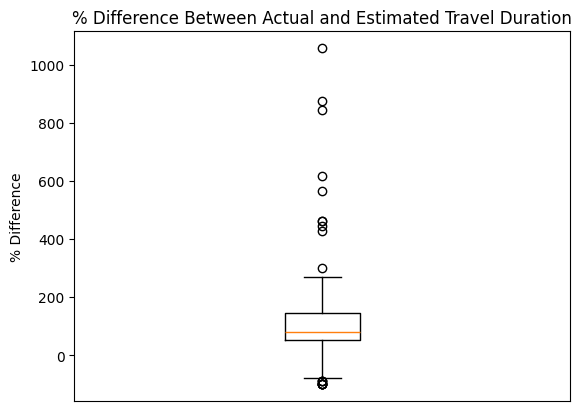

In [153]:
l_duration = []
for list in duration_percent_diff:
    for item in list:
        l_duration.append(item)
print(l_duration)
plt.boxplot(l_duration)
plt.title("% Difference Between Actual and Estimated Travel Duration")
plt.ylabel("% Difference")
plt.xticks(ticks=[], labels=[])
plt.show()

# Actual Distance Traveled Analysis

In [235]:
bots = range(1, 41, 1)

info = ""
d = 0
duration = []
distance = []
error_lines = []
for bot in bots:
    f = open("rail-desktop-3-human-text-2024081615.log", "r")
    duration_bot = []
    distance_bot = []
    for line in f:
        if 'Event of type=\"Task\"' in line:
            if 'Bot ' + str(bot) + "," in line:
                if bot == 14:
                    print(line)
                values = (line[102:].replace('actual', '').replace('duration', '').replace('distance', '').replace('expected', '').replace(' ', '').replace('ms', '').replace('mm', '').split(",")[:4])
                values = [literal_eval(x) for x in values]
                
                if values[1] == 0:
                    error_lines.append(line)
                else:
                    duration_bot.append(values[0])
                    distance_bot.append(values[2])
    duration.append(duration_bot)
    distance.append(distance_bot)

2024-08-16T15:36:18.9340474Z Info 10 [R] Event of type="Task" publishing with value="Bot 14, Task 19: 84500ms actual duration, 51945ms expected duration, 215798mm actual distance, 452146mm expected distance, 0ms start offset, 0 hops, Complete, Outbound"

2024-08-16T15:36:32.0258727Z Info 19 [R] Event of type="Task" publishing with value="Bot 14, Task 107: 19500ms actual duration, 1686ms expected duration, 1067mm actual distance, 8285mm expected distance, 0ms start offset, 0 hops, Complete, EmergencyCharge"



In [236]:
print(duration)
print(distance)

[[0], [500], [0, 12500, 73500], [500, 26000], [0, 6500, 88500], [0, 4500, 7000, 99000], [6000, 24500], [23500], [8000], [99000, 15500, 121500], [75000, 19500], [127500, 79500, 63000], [60500, 138000, 71000], [84500, 19500], [78500, 102000], [80500, 69500], [90500, 111500, 72000, 21000], [80000, 95500], [117500, 103000], [54500, 216000], [106000, 112500], [63000, 16000], [91500, 97000, 83000], [81000, 132500], [68000, 138000], [60000, 16500, 132000, 16500], [112500, 116500, 68000], [71500], [49000, 119500], [180500], [76000, 88000, 74500], [110000, 16500, 89500, 49000], [87000, 112500, 60000, 16000], [177500, 89000], [146000], [98500], [106000, 152000], [78500, 108000], [82500, 96000], [62500, 122500]]
[[147593], [276308], [113711, 211735, 163272], [84005, 159636], [126942, 173045, 192134], [327384, 1062, 230297, 191520], [229925, 282861], [66187], [99893], [330328, 3209, 284165], [166801, 3198], [269534, 162373, 135697], [62979, 187580, 144581], [215798, 1067], [187331, 255971], [17264

In [237]:
actual_distance = []
for list in distance:
    for val in list:
        actual_distance.append(val/1000)
        
actual_duration = []
for list in duration:
    for val in list:
        actual_duration.append(val/1000)


[147.593, 276.308, 113.711, 211.735, 163.272, 84.005, 159.636, 126.942, 173.045, 192.134, 327.384, 1.062, 230.297, 191.52, 229.925, 282.861, 66.187, 99.893, 330.328, 3.209, 284.165, 166.801, 3.198, 269.534, 162.373, 135.697, 62.979, 187.58, 144.581, 215.798, 1.067, 187.331, 255.971, 172.641, 93.358, 257.215, 99.964, 244.023, 3.196, 135.821, 131.633, 108.087, 187.751, 25.181, 295.404, 161.003, 60.083, 159.035, 3.211, 214.133, 163.907, 237.02, 186.414, 268.521, 77.876, 273.716, 123.035, 1.074, 176.801, 3.195, 111.267, 206.882, 167.872, 132.788, 65.035, 139.438, 124.661, 89.652, 98.955, 113.838, 182.563, 3.199, 147.432, 53.31, 210.617, 201.688, 130.41, 1.075, 240.288, 201.133, 242.398, 159.265, 180.653, 203.401, 79.636, 245.452, 175.148, 141.5, 129.637, 183.404]


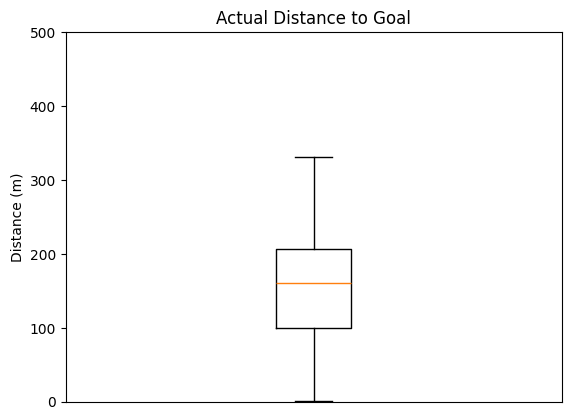

In [220]:
print(actual_distance)
plt.boxplot(actual_distance)
plt.title("Actual Distance to Goal")
plt.ylabel("Distance (m)")
plt.ylim((0, 500))
plt.xticks(ticks=[], labels=[])
plt.show()

[0.0, 0.5, 0.0, 12.5, 73.5, 0.5, 26.0, 0.0, 6.5, 88.5, 0.0, 4.5, 7.0, 99.0, 6.0, 24.5, 23.5, 8.0, 99.0, 15.5, 121.5, 75.0, 19.5, 127.5, 79.5, 63.0, 60.5, 138.0, 71.0, 84.5, 19.5, 78.5, 102.0, 80.5, 69.5, 90.5, 111.5, 72.0, 21.0, 80.0, 95.5, 117.5, 103.0, 54.5, 216.0, 106.0, 112.5, 63.0, 16.0, 91.5, 97.0, 83.0, 81.0, 132.5, 68.0, 138.0, 60.0, 16.5, 132.0, 16.5, 112.5, 116.5, 68.0, 71.5, 49.0, 119.5, 180.5, 76.0, 88.0, 74.5, 110.0, 16.5, 89.5, 49.0, 87.0, 112.5, 60.0, 16.0, 177.5, 89.0, 146.0, 98.5, 106.0, 152.0, 78.5, 108.0, 82.5, 96.0, 62.5, 122.5]


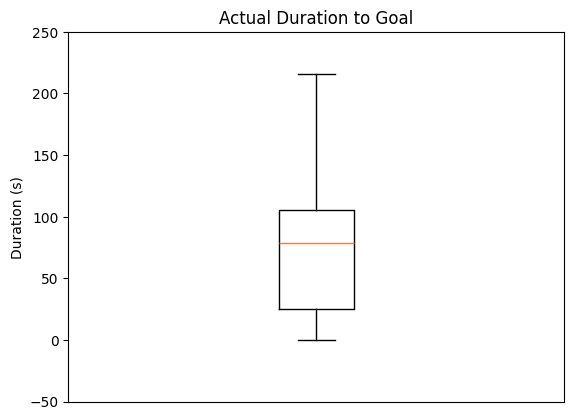

In [221]:
print(actual_duration)
plt.boxplot(actual_duration)
plt.title("Actual Duration to Goal")
plt.ylabel("Duration (s)")
plt.ylim((-50, 250))
plt.xticks(ticks=[], labels=[])
plt.show()

# Estimated Travel Distance and Duration

In [238]:
bots = range(1, 41, 1)

info = ""
d = 0
duration = []
distance = []
error_lines = []
for bot in bots:
    f = open("rail-desktop-3-human-text-2024081615.log", "r")
    duration_bot = []
    distance_bot = []
    for line in f:
        if 'Event of type=\"Task\"' in line:
            if 'Bot ' + str(bot) + "," in line:
                if bot == 14:
                    print(line)
                values = (line[102:].replace('actual', '').replace('duration', '').replace('distance', '').replace('expected', '').replace(' ', '').replace('ms', '').replace('mm', '').split(",")[:4])
                values = [literal_eval(x) for x in values]
                
                if values[1] == 0:
                    error_lines.append(line)
                else:
                    duration_bot.append(values[1])
                    distance_bot.append(values[3])
    duration.append(duration_bot)
    distance.append(distance_bot)

2024-08-16T15:36:18.9340474Z Info 10 [R] Event of type="Task" publishing with value="Bot 14, Task 19: 84500ms actual duration, 51945ms expected duration, 215798mm actual distance, 452146mm expected distance, 0ms start offset, 0 hops, Complete, Outbound"

2024-08-16T15:36:32.0258727Z Info 19 [R] Event of type="Task" publishing with value="Bot 14, Task 107: 19500ms actual duration, 1686ms expected duration, 1067mm actual distance, 8285mm expected distance, 0ms start offset, 0 hops, Complete, EmergencyCharge"



In [239]:
estimated_distance = []
for list in distance:
    for val in list:
        estimated_distance.append(val/1000)
        
estimated_duration = []
for list in duration:
    for val in list:
        estimated_duration.append(val/1000)

In [246]:
outlier = []
for i in range(len(actual_duration)):
    if actual_duration[i] < 20:
        outlier.append(i)

actual_distance = np.delete(actual_distance, outlier)
actual_duration = np.delete(actual_duration, outlier)
estimated_distance = np.delete(estimated_distance, outlier)
estimated_duration = np.delete(estimated_duration, outlier)

[]

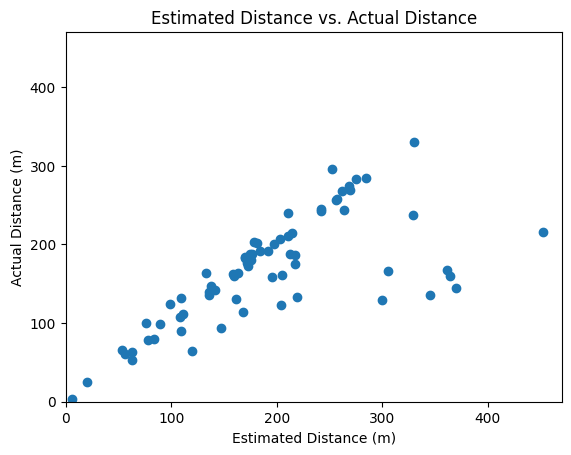

In [227]:
plt.scatter(estimated_distance, actual_distance)
plt.xlabel("Estimated Distance (m)")
plt.ylabel("Actual Distance (m)")
plt.xlim((0, 470))
plt.ylim((0, 470))
plt.title("Estimated Distance vs. Actual Distance")
plt.plot()

In [228]:
estimated_distance_bar = np.mean(estimated_distance)
actual_distance_bar = np.mean(actual_distance)

top = np.sum((estimated_distance - estimated_distance_bar) * (actual_distance - actual_distance_bar))
bot = np.sqrt(np.sum(np.power(estimated_distance - estimated_distance_bar, 2)) * np.sum(np.power(actual_distance - actual_distance_bar, 2)))

print(top/bot)

print(np.corrcoef(estimated_distance, actual_distance)[0, 1])

0.6991898833753818
0.6991898833753819


C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\1936975152.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     65.04
Date:                Wed, 28 Aug 2024   Prob (F-statistic):           1.67e-11
Time:                        16:42:19   Log-Likelihood:                -371.21
No. Observations:                  70   AIC:                             746.4
Df Residuals:                      68   BIC:                             750.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.4068     13.994      4.602      0.000      36.482      92.331
x1             0.5357      0.066      8.065      0.000       0.403       0.668
==============================================================================
Omnibus:                        2.758   Durbin-Watson:                   2.253
Prob(Omnibus):                  0.252   Jarque-Bera (JB):                2.683
Skew:                          -0.461   Prob(JB):                        0.261
Kurtosis:                       2.732   Cond. No.                         500.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

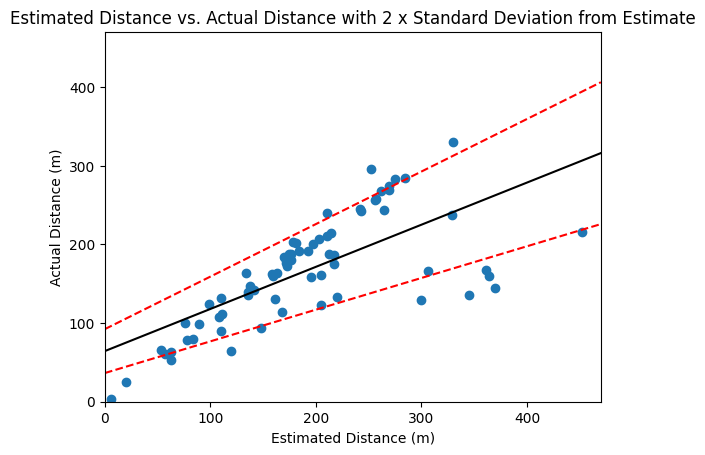

In [99]:
N = len(estimated_distance)
p = estimated_distance.shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = estimated_distance

beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ actual_distance


ols = sm.OLS(actual_distance, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(estimated_distance, actual_distance)
plt.xlabel("Estimated Distance (m)")
plt.ylabel("Actual Distance (m)")
plt.xlim((0, 470))
plt.ylim((0, 470))
plt.title("Estimated Distance vs. Actual Distance with 2 x Standard Deviation from Estimate")

x = np.linspace(0, 470, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(x, y, 'k')


y = lower_std[1]*x + lower_std[0]
plt.plot(x, y, '--r')

y = upper_std[1]*x + upper_std[0]
plt.plot(x, y, '--r')

ols_result.summary()

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\1602430685.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     23.48
Date:                Tue, 03 Sep 2024   Prob (F-statistic):           7.64e-06
Time:                        14:25:50   Log-Likelihood:                -338.42
No. Observations:                  70   AIC:                             680.8
Df Residuals:                      68   BIC:                             685.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.4965     13.569      2.174      0.033       2.419      56.574
x1             1.2961      0.267      4.846      0.000       0.762       1.830
==============================================================================
Omnibus:                       13.065   Durbin-Watson:                   1.623
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               37.546
Skew:                           0.338   Prob(JB):                     7.03e-09
Kurtosis:                       6.524   Cond. No.                         187.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

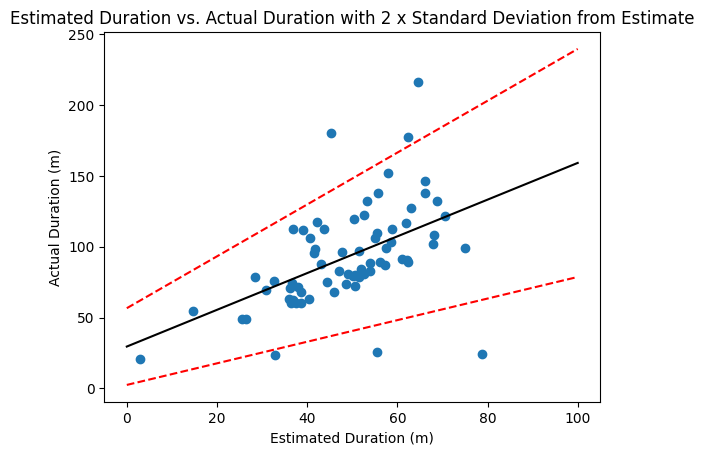

In [278]:
N = len(estimated_duration)
p = np.asarray(estimated_duration).reshape(-1, 1).shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = np.asarray(estimated_duration).reshape(-1, 1)

beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ actual_duration


ols = sm.OLS(actual_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(estimated_duration, actual_duration)
plt.xlabel("Estimated Duration (m)")
plt.ylabel("Actual Duration (m)")
plt.title("Estimated Duration vs. Actual Duration with 2 x Standard Deviation from Estimate")

x = np.linspace(0, 100, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(x, y, 'k')


y = lower_std[1]*x + lower_std[0]
plt.plot(x, y, '--r')

y = upper_std[1]*x + upper_std[0]
plt.plot(x, y, '--r')

ols_result.summary()

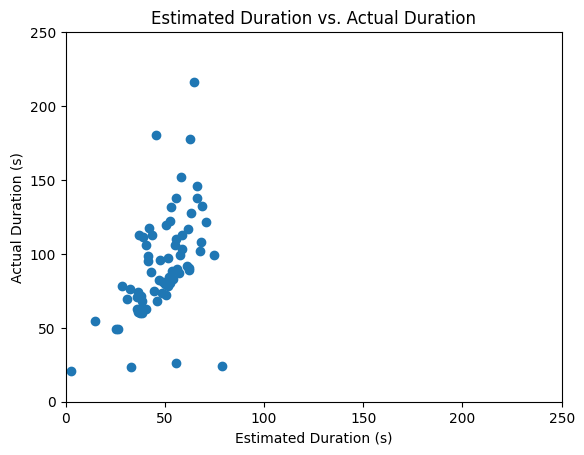

In [45]:
plt.scatter(estimated_duration, actual_duration)
plt.xlabel("Estimated Duration (s)")
plt.ylabel("Actual Duration (s)")
plt.xlim((0, 250))
plt.ylim((0, 250))
plt.title("Estimated Duration vs. Actual Duration")
plt.show()

In [16]:
print(np.corrcoef(estimated_duration, actual_duration)[0, 1])

0.501170433078875


Text(0.5, 1.0, 'Estimated Distance vs. Estimated Duration')

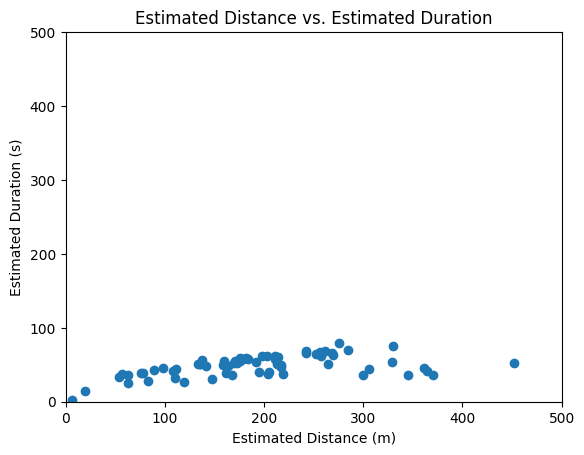

In [46]:
plt.scatter(estimated_distance, estimated_duration)
plt.xlabel("Estimated Distance (m)")
plt.ylabel("Estimated Duration (s)")
plt.xlim((0, 500))
plt.ylim((0, 500))
plt.title("Estimated Distance vs. Estimated Duration")

In [17]:
print(np.corrcoef(estimated_distance, estimated_duration)[0, 1])

0.7026030428814302


In [104]:
print(actual_duration)
print(len(actual_duration))
print(np.sort(actual_duration))
tup = []
for i in range(len(actual_duration)):
    tup.append((actual_distance[i], actual_duration[i]))
print(tup)

[0.0, 0.5, 0.0, 12.5, 73.5, 0.5, 26.0, 0.0, 6.5, 88.5, 0.0, 4.5, 7.0, 99.0, 6.0, 24.5, 23.5, 8.0, 99.0, 15.5, 121.5, 75.0, 19.5, 127.5, 79.5, 63.0, 60.5, 138.0, 71.0, 84.5, 19.5, 78.5, 102.0, 80.5, 69.5, 90.5, 111.5, 72.0, 21.0, 80.0, 95.5, 117.5, 103.0, 54.5, 216.0, 106.0, 112.5, 63.0, 16.0, 91.5, 97.0, 83.0, 81.0, 132.5, 68.0, 138.0, 60.0, 16.5, 132.0, 16.5, 112.5, 116.5, 68.0, 71.5, 49.0, 119.5, 180.5, 76.0, 88.0, 74.5, 110.0, 16.5, 89.5, 49.0, 87.0, 112.5, 60.0, 16.0, 177.5, 89.0, 146.0, 98.5, 106.0, 152.0, 78.5, 108.0, 82.5, 96.0, 62.5, 122.5]
90
[  0.    0.    0.    0.    0.5   0.5   4.5   6.    6.5   7.    8.   12.5
  15.5  16.   16.   16.5  16.5  16.5  19.5  19.5  21.   23.5  24.5  26.
  49.   49.   54.5  60.   60.   60.5  62.5  63.   63.   68.   68.   69.5
  71.   71.5  72.   73.5  74.5  75.   76.   78.5  78.5  79.5  80.   80.5
  81.   82.5  83.   84.5  87.   88.   88.5  89.   89.5  90.5  91.5  95.5
  96.   97.   98.5  99.   99.  102.  103.  106.  106.  108.  110.  111.5
 112.

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\2987723680.py:24: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     20.26
Date:                Thu, 29 Aug 2024   Prob (F-statistic):           2.72e-05
Time:                        11:34:20   Log-Likelihood:                -339.67
No. Observations:                  70   AIC:                             683.3
Df Residuals:                      68   BIC:                             687.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.3036      9.951      5.156      0.000      31.448      71.160
x1             0.2487      0.055      4.501      0.000       0.138       0.359
==============================================================================
Omnibus:                        9.785   Durbin-Watson:                   1.700
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               14.878
Skew:                           0.482   Prob(JB):                     0.000588
Kurtosis:                       5.042   Cond. No.                         477.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

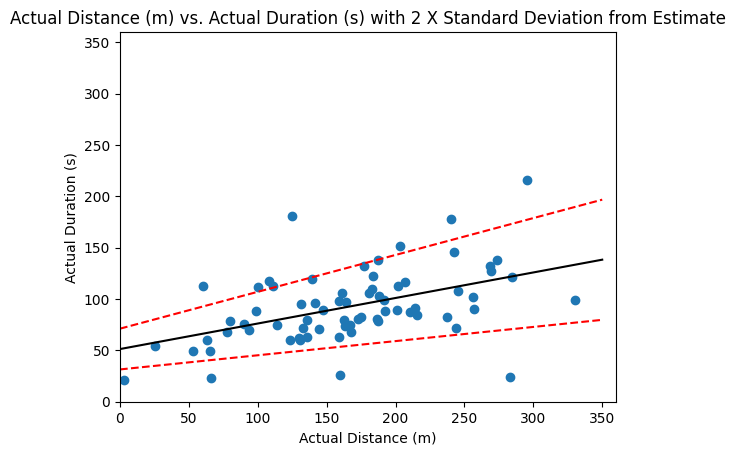

In [144]:
# plt.scatter(actual_distance, actual_duration)
# plt.xlabel("Actual Distance (m)")
# plt.ylabel("Actual Duration (s)")
# plt.title("Actual Distance vs. Actual Duration")
# plt.xlim((0, 350))
# plt.ylim((0, 350))

N = len(actual_distance)
p = actual_distance.shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = actual_distance


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ np.reshape(np.asarray(actual_duration), (-1, 1))


ols = sm.OLS(actual_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(actual_distance, actual_duration)
plt.xlabel("Actual Distance (m)")
plt.ylabel("Actual Duration (s)")
plt.title("Actual Distance (m) vs. Actual Duration (s) with 2 X Standard Deviation from Estimate")
plt.xlim((0, 360))
plt.ylim((0, 360))


x = np.linspace(0, 350, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(x, y, 'k')


y = lower_std[1]*x + lower_std[0]
plt.plot(x, y, '--r')

y = upper_std[1]*x + upper_std[0]
plt.plot(x, y, '--r')

ols_result.summary()

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\254003223.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     376.6
Date:                Thu, 29 Aug 2024   Prob (F-statistic):           1.97e-29
Time:                        11:34:53   Log-Likelihood:                -217.33
No. Observations:                  70   AIC:                             438.7
Df Residuals:                      68   BIC:                             443.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.6787      1.733     10.202      0.000      14.221      21.137
x1             0.1867      0.010     19.406      0.000       0.168       0.206
==============================================================================
Omnibus:                        1.745   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.418   Jarque-Bera (JB):                1.747
Skew:                          -0.353   Prob(JB):                        0.418
Kurtosis:                       2.685   Cond. No.                         477.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

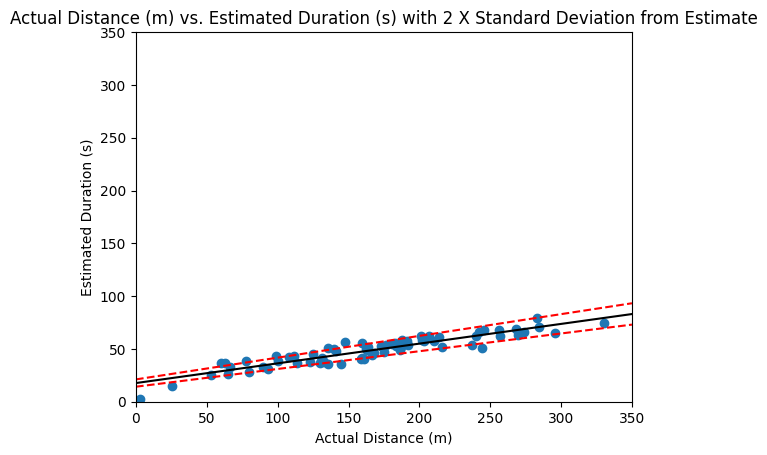

In [145]:
N = len(actual_distance)
p = actual_distance.shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = actual_distance


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ np.reshape(np.asarray(estimated_duration), (-1, 1))


ols = sm.OLS(estimated_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(actual_distance, estimated_duration)
plt.xlabel("Actual Distance (m)")
plt.ylabel("Estimated Duration (s)")
plt.title("Actual Distance (m) vs. Estimated Duration (s) with 2 X Standard Deviation from Estimate")
plt.xlim((0, 350))
plt.ylim((0, 350))


x = np.linspace(0, 350, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(x, y, 'k')


y = lower_std[1]*x + lower_std[0]
plt.plot(x, y, '--r')

y = upper_std[1]*x + upper_std[0]
plt.plot(x, y, '--r')

ols_result.summary()

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\725427440.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]
C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\725427440.py:61: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     376.6
Date:                Tue, 03 Sep 2024   Prob (F-statistic):           1.97e-29
Time:                        11:56:35   Log-Likelihood:                -217.33
No. Observations:                  70   AIC:                             438.7
Df Residuals:                      68   BIC:                             443.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.6787      1.733     10.202      0.000      14.221      21.137
x1             0.1867      0.010     19.406      0.000       0.168       0.206
==============================================================================
Omnibus:                        1.745   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.418   Jarque-Bera (JB):                1.747
Skew:                          -0.353   Prob(JB):                        0.418
Kurtosis:                       2.685   Cond. No.                         477.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

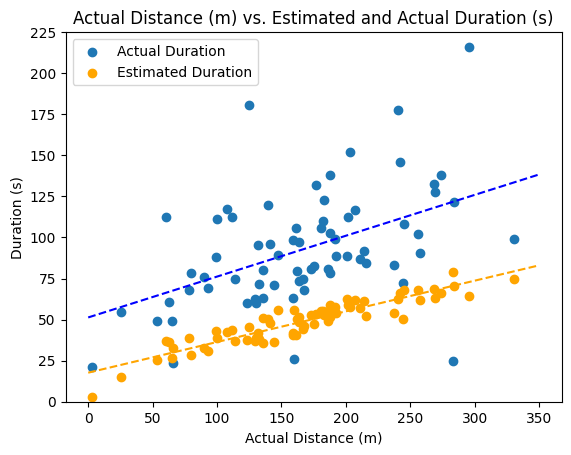

In [250]:
N = len(actual_distance)
p = np.asarray(actual_distance).reshape(-1, 1).shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = np.asarray(actual_distance).reshape(-1, 1)


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ np.reshape(np.asarray(actual_duration), (-1, 1))


ols = sm.OLS(actual_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(actual_distance, actual_duration, label="Actual Duration")
plt.ylim((0, 225))
plt.ylabel("Duration (s)")
plt.xlabel("Actual Distance (m)")
plt.title("Actual Distance (m) vs. Estimated and Actual Duration (s)")
# plt.xlim((0, 360))
# plt.ylim((0, 360))

x = np.linspace(0, 350, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(x, y, '--b')


# y = lower_std[1]*x + lower_std[0]
# plt.plot(x, y, '--g')

# y = upper_std[1]*x + upper_std[0]
# plt.plot(x, y, '--g')

ols_result.summary()


N = len(actual_distance)
p = np.asarray(actual_distance).reshape((-1, 1)).shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = np.asarray(actual_distance).reshape((-1, 1))


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ np.reshape(np.asarray(estimated_duration), (-1, 1))


ols = sm.OLS(estimated_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(actual_distance, estimated_duration, color='#FFA500', label="Estimated Duration")
# plt.xlabel("Actual Distance (m)")
# plt.ylabel("Estimated Duration (s)")
# plt.title("Actual Distance (m) vs. Estimated Duration (s) with 2 X Standard Deviation from Estimate")
# plt.xlim((0, 350))
# plt.ylim((0, 350))


x = np.linspace(0, 350, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(x, y, '--', color='#FFA500')
plt.legend()

# y = lower_std[1]*x + lower_std[0]
# plt.plot(x, y, '--r')

# y = upper_std[1]*x + upper_std[0]
# plt.plot(x, y, '--r')

ols_result.summary()

Text(0.5, 1.0, 'Estimated Distance (m) vs. Duration Percentage Error ')

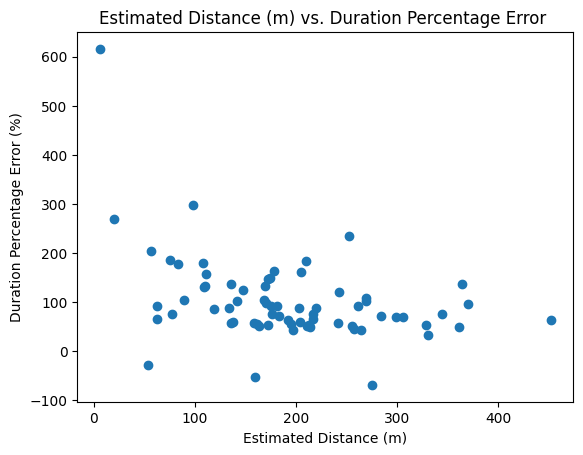

In [104]:
percent_diff_duration = []
for i in range(len(actual_duration)):
    diff = ((actual_duration[i] - estimated_duration[i])/estimated_duration[i])*100
    percent_diff_duration.append(diff)

plt.scatter(estimated_distance, percent_diff_duration)
plt.xlabel("Estimated Distance (m)")
plt.ylabel("Duration Percentage Error (%)")
plt.title("Estimated Distance (m) vs. Duration Percentage Error ")

In [ ]:
plt.scatter(actual_duration)

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\4112551430.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     13.14
Date:                Tue, 03 Sep 2024   Prob (F-statistic):           0.000553
Time:                        10:00:13   Log-Likelihood:                -406.28
No. Observations:                  70   AIC:                             816.6
Df Residuals:                      68   BIC:                             821.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        177.9395     23.095      7.705      0.000     131.854     224.025
x1            -0.3974      0.110     -3.625      0.001      -0.616      -0.179
==============================================================================
Omnibus:                       57.982   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              437.444
Skew:                           2.227   Prob(JB):                     1.02e-95
Kurtosis:                      14.408   Cond. No.                         500.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

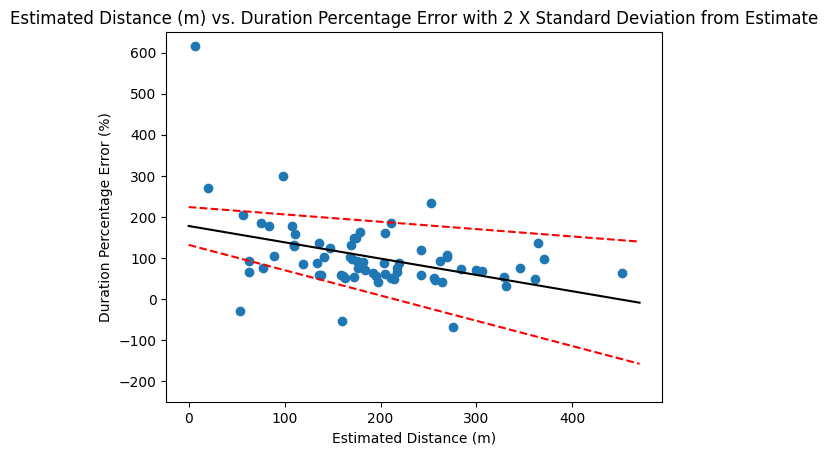

In [214]:
N = len(estimated_distance)
p = estimated_distance.shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = estimated_distance


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ np.reshape(np.asarray(percent_diff_duration), (-1, 1))


ols = sm.OLS(percent_diff_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(estimated_distance, percent_diff_duration)
plt.xlabel("Estimated Distance (m)")
plt.ylabel("Duration Percentage Error (%)")
plt.title("Estimated Distance (m) vs. Duration Percentage Error with 2 X Standard Deviation from Estimate")
plt.ylim((-250, 650))

x = np.linspace(0, 470, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(x, y, 'k')


y = lower_std[1]*x + lower_std[0]
plt.plot(x, y, '--r')

y = upper_std[1]*x + upper_std[0]
plt.plot(x, y, '--r')

ols_result.summary()

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\2388813876.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     12.28
Date:                Fri, 30 Aug 2024   Prob (F-statistic):           0.000816
Time:                        11:21:51   Log-Likelihood:                -406.65
No. Observations:                  70   AIC:                             817.3
Df Residuals:                      68   BIC:                             821.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        186.0687     25.906      7.182      0.000     134.374     237.763
x1            -0.5040      0.144     -3.504      0.001      -0.791      -0.217
==============================================================================
Omnibus:                       57.070   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              373.370
Skew:                           2.257   Prob(JB):                     8.39e-82
Kurtosis:                      13.375   Cond. No.                         477.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

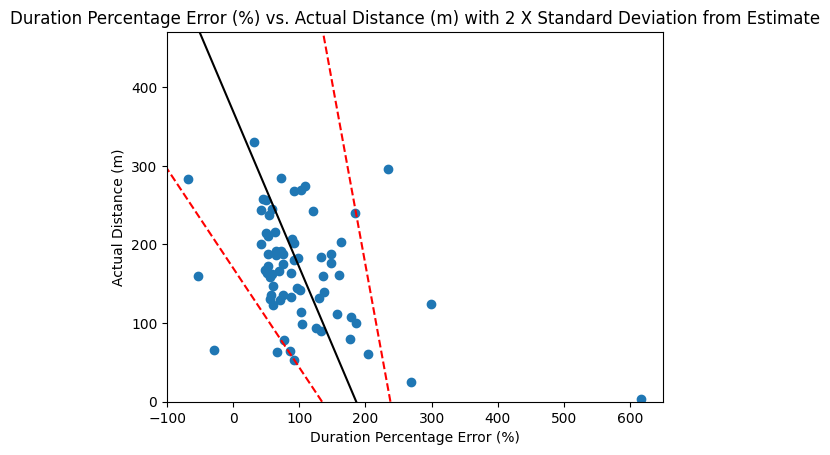

In [200]:
N = len(actual_distance)
p = actual_distance.shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = actual_distance


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ np.reshape(np.asarray(percent_diff_duration), (-1, 1))


ols = sm.OLS(percent_diff_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(percent_diff_duration, actual_distance)
plt.ylabel("Actual Distance (m)")
plt.xlabel("Duration Percentage Error (%)")
plt.xlim((-100, 650))
plt.ylim((0, 470))
plt.title("Duration Percentage Error (%) vs. Actual Distance (m) with 2 X Standard Deviation from Estimate")

x = np.linspace(0, 470, 100)
y = linear_regression[1]*x + linear_regression[0]
plt.plot(y, x, 'k')


y = lower_std[1]*x + lower_std[0]
plt.plot(y, x, '--r')

y = upper_std[1]*x + upper_std[0]
plt.plot(y, x, '--r')

ols_result.summary()

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\1482996872.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]
C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\1482996872.py:63: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     12.28
Date:                Tue, 03 Sep 2024   Prob (F-statistic):           0.000816
Time:                        09:52:59   Log-Likelihood:                -388.89
No. Observations:                  70   AIC:                             781.8
Df Residuals:                      68   BIC:                             786.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        197.7103     11.647     16.975      0.000     174.469     220.952
x1            -0.3034      0.087     -3.504      0.001      -0.476      -0.131
==============================================================================
Omnibus:                        0.978   Durbin-Watson:                   2.480
Prob(Omnibus):                  0.613   Jarque-Bera (JB):                0.784
Skew:                           0.258   Prob(JB):                        0.676
Kurtosis:                       2.955   Cond. No.                         206.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

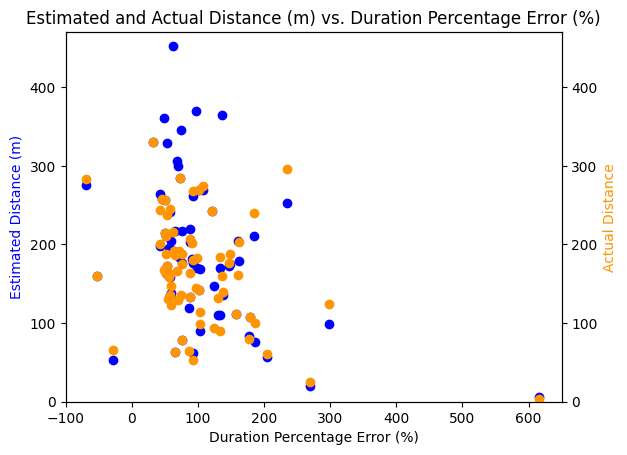

In [213]:
N = len(percent_diff_duration)
p = np.reshape(np.asarray(percent_diff_duration), (-1, 1)).shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = np.reshape(np.asarray(percent_diff_duration), (-1, 1))


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ estimated_distance


ols = sm.OLS(estimated_distance, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.scatter(percent_diff_duration, estimated_distance, label="Estimated Distance", color='b')
ax1.set_ylabel("Estimated Distance (m)", color='b')
ax1.set_xlabel("Duration Percentage Error (%)")
ax1.set_ylim((0, 470))
plt.title("Estimated and Actual Distance (m) vs. Duration Percentage Error (%)")
plt.xlim((-100, 650))

# x = np.linspace(0, 470, 100)
# y = linear_regression[1]*x + linear_regression[0]
# plt.plot(x, y, '-b', label="Estimated Distance Linear Regression")


# y = lower_std[1]*x + lower_std[0]
# plt.plot(x, y, '--b', label="Estimated Distance 2 Std.")

# y = upper_std[1]*x + upper_std[0]
# plt.plot(x, y, '--b')

ols_result.summary()

N = len(percent_diff_duration)
p = np.reshape(np.asarray(percent_diff_duration), (-1, 1)).shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = np.reshape(np.asarray(percent_diff_duration), (-1, 1))


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ actual_distance


ols = sm.OLS(actual_distance, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

ax2.scatter(percent_diff_duration, actual_distance, label="Actual Distance (m)", color="#ff9500")
ax2.set_ylabel("Actual Distance", color="#ff9500")
ax2.set_ylim((0, 470))

# x = np.linspace(0, 470, 100)
# y = linear_regression[1]*x + linear_regression[0]
# plt.plot(x, y, '-', color="#FFA500", label="Actual Distance Linear Regression")


# y = lower_std[1]*x + lower_std[0]
# plt.plot(x, y, '--', color="#FFA500", label="Actual Distance 2 Std.")

# y = upper_std[1]*x + upper_std[0]
# plt.plot(x, y, '--', color="#FFA500")

# plt.legend()
ols_result.summary()

C:\Users\Ethan\AppData\Local\Temp\ipykernel_4068\2168993641.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(results_as_html, header=0, index_col=0)[0]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                   0.02013
Date:                Fri, 30 Aug 2024   Prob (F-statistic):              0.888
Time:                        11:26:58   Log-Likelihood:                -412.45
No. Observations:                  70   AIC:                             828.9
Df Residuals:                      68   BIC:                             833.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        102.5109     11.181      9.168      0.000      80.199     124.823
x1             0.0665      0.469      0.142      0.888      -0.869       1.002
==============================================================================
Omnibus:                       74.547   Durbin-Watson:                   1.863
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              796.471
Skew:                           3.008   Prob(JB):                    1.12e-173
Kurtosis:                      18.391   Cond. No.                         25.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

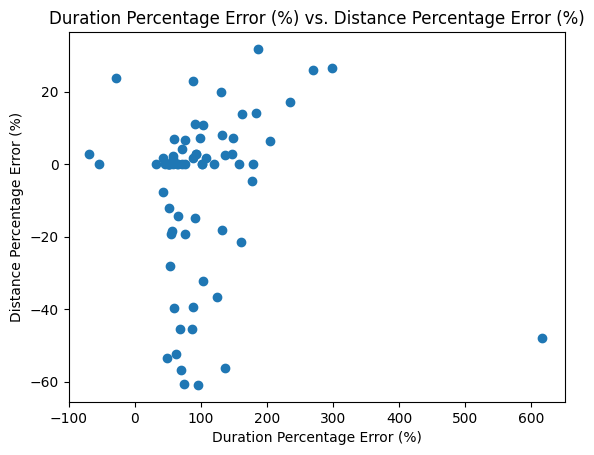

In [203]:
percent_diff_distance = []
for i in range(len(actual_distance)):
    diff = ((actual_distance[i] - estimated_distance[i])/estimated_distance[i])*100
    percent_diff_distance.append(diff)
percent_diff_distance = np.asarray(percent_diff_distance)

N = len(percent_diff_distance)
p = percent_diff_distance.shape[1] + 1  # plus one because LinearRegression adds an intercept term

X_with_intercept = np.empty(shape=(N, p))
X_with_intercept[:, 0] = 1
X_with_intercept[:, 1:p] = percent_diff_distance


beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ np.reshape(np.asarray(percent_diff_duration), (-1, 1))


ols = sm.OLS(percent_diff_duration, X_with_intercept)
ols_result = ols.fit()
results_summary = ols_result.summary()

results_as_html = results_summary.tables[1].as_html()
df = pd.read_html(results_as_html, header=0, index_col=0)[0]

linear_regression = df['coef'].to_list()
lower_std = df['[0.025'].to_list()
upper_std = df['0.975]'].to_list()

plt.scatter(percent_diff_duration, percent_diff_distance)
plt.ylabel("Distance Percentage Error (%)")
plt.xlabel("Duration Percentage Error (%)")
plt.title("Duration Percentage Error (%) vs. Distance Percentage Error (%)")
plt.xlim((-100, 650))

# x = np.linspace(-80, 40, 100)
# y = linear_regression[1]*x + linear_regression[0]
# plt.plot(x, y, 'k')


# y = lower_std[1]*x + lower_std[0]
# plt.plot(x, y, '--r')

# y = upper_std[1]*x + upper_std[0]
# plt.plot(x, y, '--r')

ols_result.summary()

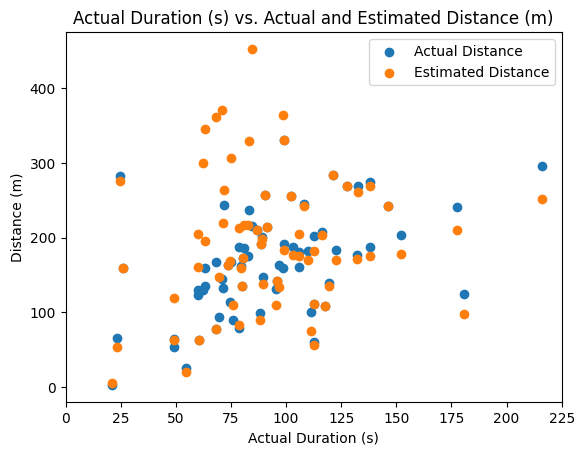

In [251]:
plt.scatter(actual_duration, actual_distance, label="Actual Distance")
plt.scatter(actual_duration, estimated_distance, label="Estimated Distance")
plt.ylabel("Distance (m)")
plt.xlabel("Actual Duration (s)")
plt.xlim((0, 225))
plt.title("Actual Duration (s) vs. Actual and Estimated Distance (m)")
plt.legend()

Text(0.5, 1.0, 'Actual Duration (s) vs. Distance Percent Difference (%)')

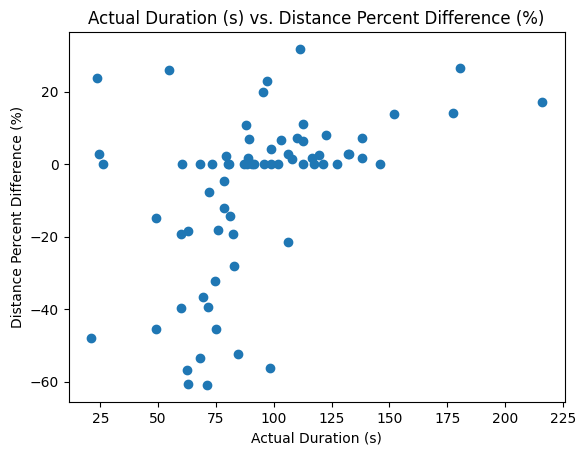

In [254]:
percent_diff_distance = []
for i in range(len(actual_distance)):
    diff = ((actual_distance[i] - estimated_distance[i])/estimated_distance[i])*100
    percent_diff_distance.append(diff)
percent_diff_distance = np.asarray(percent_diff_distance)

plt.scatter(actual_duration, percent_diff_distance)
plt.xlabel("Actual Duration (s)")
plt.ylabel("Distance Percent Difference (%)")
plt.title("Actual Duration (s) vs. Distance Percent Difference (%)")


Text(0.5, 1.0, 'Actual Distance (s) vs. Duration Percent Difference (%)')

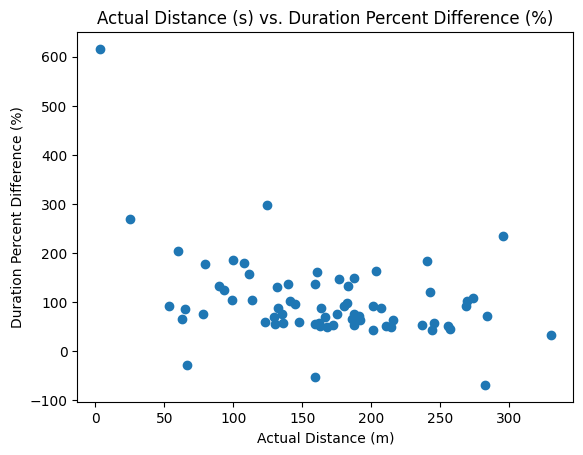

In [267]:
percent_diff_duration = []
for i in range(len(actual_duration)):
    diff = ((actual_duration[i] - estimated_duration[i])/estimated_duration[i])*100
    percent_diff_duration.append(diff)
    
plt.scatter(actual_distance, percent_diff_duration)
plt.xlabel("Actual Distance (m)")
plt.ylabel("Duration Percent Difference (%)")
plt.title("Actual Distance (s) vs. Duration Percent Difference (%)")

In [266]:
print(len(percent_diff_distance))
print(len(percent_diff_distance[percent_diff_distance[:] < -5]))
print(len(percent_diff_distance[percent_diff_distance[:] > 5]))

70
23
17


# Speed Analysis

In [211]:
bots = range(1, 41, 1)

queue = []
queue_limit = 14
keyword = "LinearVelocity"

info = ""
d = 0
speeds = []
for bot in bots:
    f = open("rail-desktop-3-human-text-2024081615.log", "r")
    for line in f:
        queue = []
        if 'Message Symbotic.SystemState.Event.Bot.Updated' in line:
            if 'bot ' + str(bot) + "," in line:
                # Start enumerating over the line of text
                for i, character in enumerate(line):
                    queue.append(character)
                    # if the queue if full, check if keyword is present: if it is, then gather next characters, if it is not, 
                    if len(queue) == queue_limit:
                        if keyword in ''.join(queue):
                            word = ""
                            for character in line[(i+1):]:
                                if character == ",":
                                    word = word.replace('mm/s', '').replace(':', '').replace(' ', '')
                                    speeds.append(np.abs(literal_eval(word)))
                                    break
                                else:
                                    word += str(character)
                            break
                        else:
                            queue.pop(0)
print(speeds)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 390, 390,

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

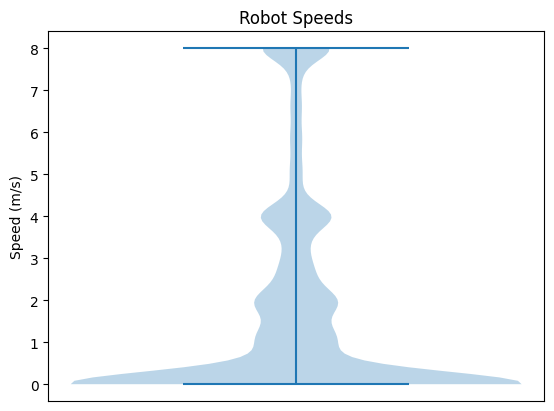

In [217]:
adjusted_speeds = [x/1000 for x in speeds]
print(adjusted_speeds)
plt.violinplot(adjusted_speeds)
plt.title("Robot Speeds")
plt.ylabel("Speed (m/s)")
plt.xticks(ticks=[], labels=[])
plt.show()

# Idle State

In [1]:
bots = range(1, 41, 1)

queue = []
keyword = "OperationalState"
queue_limit = len(keyword)

info = ""
d = 0
idle_count = 0
active_count = 0
for bot in bots:
    f = open("rail-desktop-3-human-text-2024081615.log", "r")
    for line in f:
        queue = []
        if 'Message Symbotic.SystemState.Event.Bot.Updated' in line:
            if 'bot ' + str(bot) + "," in line:
                # Start enumerating over the line of text
                for i, character in enumerate(line):
                    queue.append(character)
                    # if the queue if full, check if keyword is present: if it is, then gather next characters, if it is not, 
                    if len(queue) == queue_limit:
                        if keyword in ''.join(queue):
                            word = ""
                            for character in line[(i+1):]:
                                if character == "}":
                                    word = word.replace('mm/s', '').replace(':', '').replace(' ', '')
                                    if word == "Idle":
                                        idle_count += 1
                                    elif word == "Active":
                                        active_count += 1
                                    else:
                                        print("Not a known word: ", word)
                                    break
                                else:
                                    word += str(character)
                            break
                        else:
                            queue.pop(0)
print(idle_count)
print(active_count)

20888
27112


In [3]:
print("Robots are idle " + str((idle_count / (idle_count + active_count))*100) + "% of the time")

Robots are idle 43.516666666666666% of the time


# Frequency Plot

In [9]:
bots = range(1, 41, 1)

queue = []
keyword = "OperationalState"
queue_limit = len(keyword)

d = 0
idle_times = []
active_times = []

active_count = 0
idle_count = 0
in_section = False

f = open("rail-desktop-3-human-text-2024081615.log", "r")
for line in f:
    queue = []
    if 'Message Symbotic.SystemState.Event.Bot.Updated' not in line and in_section:
        idle_times.append(idle_count)
        active_times.append(active_count)
        
        idle_count = 0
        active_count = 0
        
        in_section = False
        
    if 'Message Symbotic.SystemState.Event.Bot.Updated' in line:
        in_section = True
        # Start enumerating over the line of text
        for i, character in enumerate(line):
            queue.append(character)
            # if the queue if full, check if keyword is present: if it is, then gather next characters, if it is not, 
            if len(queue) == queue_limit:
                if keyword in ''.join(queue):
                    word = ""
                    for character in line[(i+1):]:
                        if character == "}":
                            word = word.replace('mm/s', '').replace(':', '').replace(' ', '')
                            if word == "Idle":
                                idle_count += 1
                            elif word == "Active":
                                active_count += 1
                            else:
                                print("Not a known word: ", word)
                            break
                        else:
                            word += str(character)
                    break
                else:
                    queue.pop(0)
print(idle_times)
print(active_times)

[80, 56, 56, 56, 56, 48, 48, 46, 46, 46, 54, 48, 48, 46, 46, 46, 46, 46, 44, 44, 44, 42, 42, 40, 36, 32, 32, 30, 34, 30, 30, 30, 30, 32, 36, 36, 36, 38, 40, 38, 38, 40, 40, 40, 40, 44, 42, 42, 44, 42, 40, 42, 40, 44, 40, 40, 38, 34, 36, 36, 38, 40, 40, 42, 38, 38, 38, 42, 42, 44, 42, 40, 40, 40, 42, 40, 40, 36, 36, 38, 40, 38, 38, 40, 40, 40, 34, 40, 42, 40, 38, 38, 38, 38, 38, 36, 34, 34, 34, 36, 32, 23, 5, 30, 28, 26, 28, 30, 30, 32, 28, 28, 28, 30, 30, 32, 34, 32, 34, 32, 32, 36, 34, 30, 30, 30, 32, 32, 36, 38, 40, 40, 40, 38, 34, 36, 34, 34, 30, 30, 30, 28, 30, 26, 4, 34, 34, 32, 34, 34, 32, 32, 32, 34, 36, 32, 34, 36, 36, 40, 42, 42, 40, 38, 38, 30, 30, 30, 30, 30, 30, 28, 28, 28, 32, 32, 28, 26, 26, 28, 30, 30, 34, 32, 34, 34, 32, 36, 34, 34, 36, 40, 40, 42, 38, 36, 36, 34, 38, 44, 44, 40, 38, 38, 36, 36, 36, 36, 36, 34, 32, 30, 32, 30, 30, 28, 30, 32, 30, 30, 32, 34, 36, 36, 34, 30, 30, 32, 26, 28, 28, 32, 32, 30, 32, 36, 36, 38, 36, 38, 38, 40, 42, 42, 44, 40, 38, 38, 38, 38, 4

In [10]:
idle_times = [int(x/2) for x in idle_times]
print(idle_times)
print(len(idle_times))
print(len(idle_times[:600]))
print(np.linspace(0, 300, 601))

[40, 28, 28, 28, 28, 24, 24, 23, 23, 23, 27, 24, 24, 23, 23, 23, 23, 23, 22, 22, 22, 21, 21, 20, 18, 16, 16, 15, 17, 15, 15, 15, 15, 16, 18, 18, 18, 19, 20, 19, 19, 20, 20, 20, 20, 22, 21, 21, 22, 21, 20, 21, 20, 22, 20, 20, 19, 17, 18, 18, 19, 20, 20, 21, 19, 19, 19, 21, 21, 22, 21, 20, 20, 20, 21, 20, 20, 18, 18, 19, 20, 19, 19, 20, 20, 20, 17, 20, 21, 20, 19, 19, 19, 19, 19, 18, 17, 17, 17, 18, 16, 11, 2, 15, 14, 13, 14, 15, 15, 16, 14, 14, 14, 15, 15, 16, 17, 16, 17, 16, 16, 18, 17, 15, 15, 15, 16, 16, 18, 19, 20, 20, 20, 19, 17, 18, 17, 17, 15, 15, 15, 14, 15, 13, 2, 17, 17, 16, 17, 17, 16, 16, 16, 17, 18, 16, 17, 18, 18, 20, 21, 21, 20, 19, 19, 15, 15, 15, 15, 15, 15, 14, 14, 14, 16, 16, 14, 13, 13, 14, 15, 15, 17, 16, 17, 17, 16, 18, 17, 17, 18, 20, 20, 21, 19, 18, 18, 17, 19, 22, 22, 20, 19, 19, 18, 18, 18, 18, 18, 17, 16, 15, 16, 15, 15, 14, 15, 16, 15, 15, 16, 17, 18, 18, 17, 15, 15, 16, 13, 14, 14, 16, 16, 15, 16, 18, 18, 19, 18, 19, 19, 20, 21, 21, 22, 20, 19, 19, 19, 19, 2

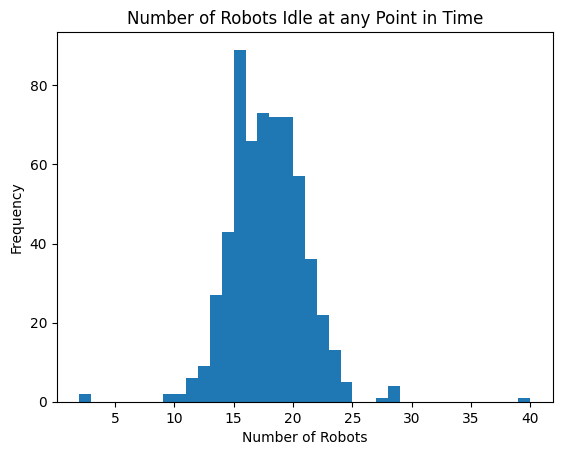

In [15]:
idle_times = np.asarray(idle_times)
plt.hist(idle_times, bins=np.arange(idle_times.min(), idle_times.max()+1))
plt.title("Number of Robots Idle at any Point in Time")
plt.xlabel("Number of Robots")
plt.ylabel("Frequency")
plt.show()

Text(0.5, 1.0, 'Idle Robots over Time')

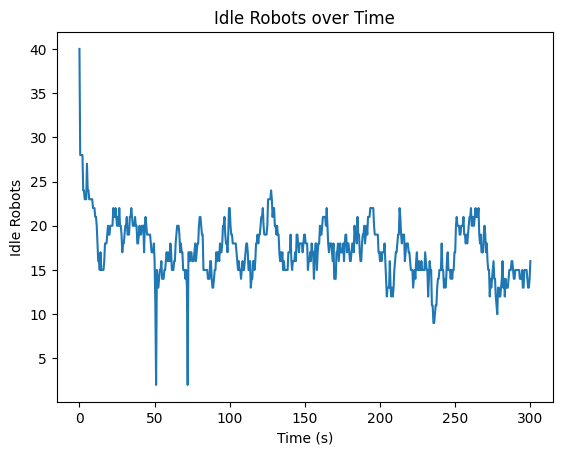

In [11]:
plt.plot(np.linspace(0, 300, 601), idle_times[:601])
plt.xlabel("Time (s)")
plt.ylabel("Idle Robots")
plt.title("Idle Robots over Time")

In [12]:
print(idle_times)

[40, 28, 28, 28, 28, 24, 24, 23, 23, 23, 27, 24, 24, 23, 23, 23, 23, 23, 22, 22, 22, 21, 21, 20, 18, 16, 16, 15, 17, 15, 15, 15, 15, 16, 18, 18, 18, 19, 20, 19, 19, 20, 20, 20, 20, 22, 21, 21, 22, 21, 20, 21, 20, 22, 20, 20, 19, 17, 18, 18, 19, 20, 20, 21, 19, 19, 19, 21, 21, 22, 21, 20, 20, 20, 21, 20, 20, 18, 18, 19, 20, 19, 19, 20, 20, 20, 17, 20, 21, 20, 19, 19, 19, 19, 19, 18, 17, 17, 17, 18, 16, 11, 2, 15, 14, 13, 14, 15, 15, 16, 14, 14, 14, 15, 15, 16, 17, 16, 17, 16, 16, 18, 17, 15, 15, 15, 16, 16, 18, 19, 20, 20, 20, 19, 17, 18, 17, 17, 15, 15, 15, 14, 15, 13, 2, 17, 17, 16, 17, 17, 16, 16, 16, 17, 18, 16, 17, 18, 18, 20, 21, 21, 20, 19, 19, 15, 15, 15, 15, 15, 15, 14, 14, 14, 16, 16, 14, 13, 13, 14, 15, 15, 17, 16, 17, 17, 16, 18, 17, 17, 18, 20, 20, 21, 19, 18, 18, 17, 19, 22, 22, 20, 19, 19, 18, 18, 18, 18, 18, 17, 16, 15, 16, 15, 15, 14, 15, 16, 15, 15, 16, 17, 18, 18, 17, 15, 15, 16, 13, 14, 14, 16, 16, 15, 16, 18, 18, 19, 18, 19, 19, 20, 21, 21, 22, 20, 19, 19, 19, 19, 2

In [16]:
print(len(idle_times))
print(np.mean(idle_times))


602
17.34717607973422


17.845514950166113


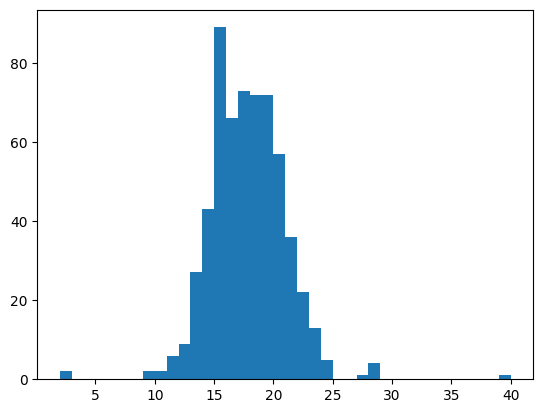

In [19]:
n, bins, patches = plt.hist(idle_times, bins=np.arange(idle_times.min(), idle_times.max()+1))

s = 0
for i in range(len(n)):
   s += n[i] * ((bins[i] + bins[i+1]) / 2) 
mean = s / np.sum(n)

print(mean)

In [21]:
t = 0
for i in range(len(n)):
  t += n[i]*(bins[i] - mean)**2
std = np.sqrt(t / np.sum(n))
print(std)

3.213507850970377
